In [1]:
import sys
sys.path.append('..')

In [2]:
# Импорты
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime
from tqdm import tqdm

from utils import generate_data, plot_comparison, plot_samples, load_wind_data, build_wind_windows
from models.eulerSDE import EulerSDE, free_energy

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"device={DEVICE}")

device=cpu


# 1. Synthetic — воспроизводим эксперимент из статьи

In [ ]:
S_D = 10
S_N_OBS = 10000
S_N_STEPS = 64
S_N_ITERS = 10000
S_BATCH = 128
S_LR = 1e-3
S_SIGMA_OBS = 0.1
S_HIDDEN = 64

In [4]:
A_true = torch.randn(S_D, S_D)
Y_data = generate_data(A_true, n_obs=S_N_OBS, n_steps=S_N_STEPS)

In [5]:
class SyntheticModelDrift(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))

    def forward(self, t, x):
        t_emb = t.expand(x.shape[0], 1) if x.dim() > 1 else t.unsqueeze(0)
        return self.net(torch.cat([x, t_emb], dim=-1))

class SyntheticVariationalDrift(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d * 2 + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))

    def forward(self, t, x, y):
        t_emb = t.expand(x.shape[0], 1) if x.dim() > 1 else t.unsqueeze(0)
        return self.net(torch.cat([x, y, t_emb], dim=-1))

class SyntheticDiffusion(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))

    def forward(self, t, x):
        t_emb = t.expand(x.shape[0], 1) if x.dim() > 1 else t.unsqueeze(0)
        return torch.exp(self.net(torch.cat([x, t_emb], dim=-1)))

100%|██████████| 4/4 [00:00<00:00, 15.98it/s]


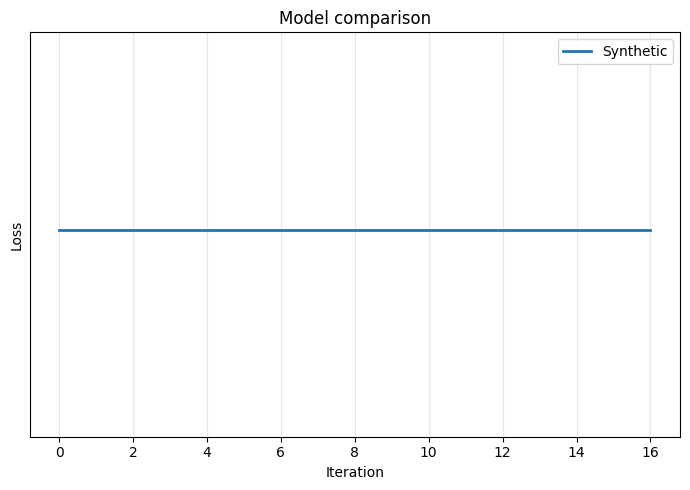

In [6]:
synthetic_model = EulerSDE(
    d=S_D,
    model_drift=SyntheticModelDrift(S_D, S_HIDDEN),
    variational_drift=SyntheticVariationalDrift(S_D, S_HIDDEN),
    diffusion=SyntheticDiffusion(S_D, S_HIDDEN))

optimizer = torch.optim.Adam(synthetic_model.parameters(), lr=S_LR)
losses_synthetic = []

for i in tqdm(range(S_N_ITERS)):
    optimizer.zero_grad()
    idx = torch.randint(0, len(Y_data), (S_BATCH,))
    y_batch = Y_data[idx]
    x0 = torch.zeros(S_BATCH, S_D)
    x1, kl = synthetic_model(x0, S_N_STEPS, y=y_batch)
    loss = free_energy(x1, kl, y_batch, sigma_obs=S_SIGMA_OBS)
    loss.backward()
    optimizer.step()
    losses_synthetic.append(loss.item())

plot_comparison({"Synthetic": losses_synthetic})

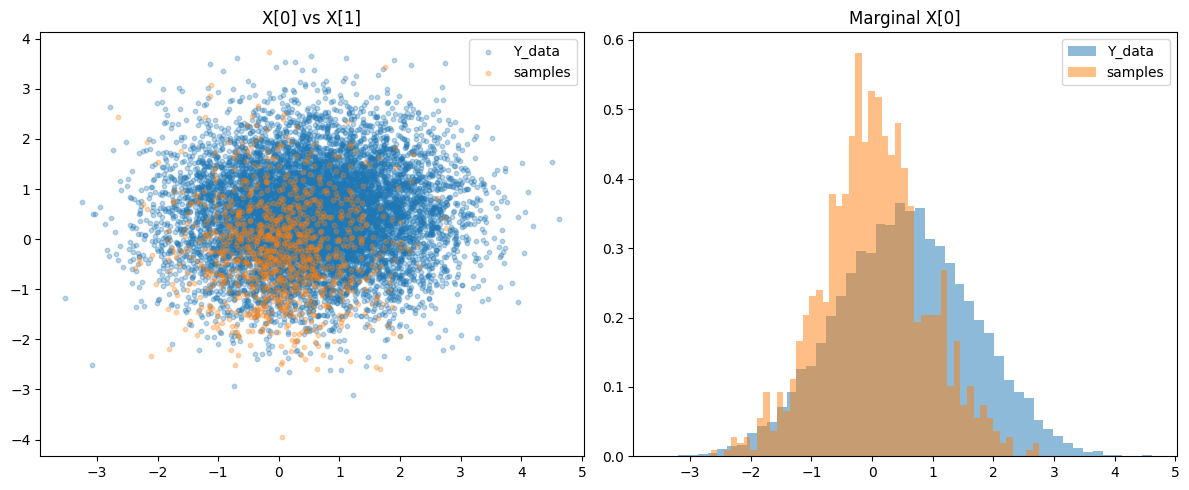

In [7]:
synthetic_model.eval()
with torch.no_grad():
    idx = torch.randint(0, len(Y_data), (1000,))
    x0 = torch.zeros(1000, S_D)
    samples, _ = synthetic_model(x0, S_N_STEPS, y=Y_data[idx])

plot_samples(Y_data, samples)